In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"keremmertnet","key":"d09056a58874b43292faf21d038fc89d"}'}

In [ ]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [ ]:
!pip install kaggle
!kaggle datasets download -d akashshingha850/mrl-eye-dataset

Dataset URL: https://www.kaggle.com/datasets/akashshingha850/mrl-eye-dataset
License(s): MIT
100% 329M/329M [00:24<00:00, 13.9MB/s]



In [ ]:
!cp mrl-eye-dataset.zip /content/drive/MyDrive/havelsandataset

In [ ]:
!ls /content/drive/MyDrive/havelsandataset

mrl-eye-dataset  mrl-eye-dataset.zip


In [ ]:
!unzip /content/drive/MyDrive/havelsandataset/mrl-eye-dataset.zip -d /content/drive/MyDrive/havelsandataset/mrl-eye-dataset

Streaming output truncated to the last 5000 lines.
  inflating: /content/drive/MyDrive/havelsandataset/mrl-eye-dataset/data/val/sleepy/s0013_02688_0_1_0_0_0_01.png  
  inflating: /content/drive/MyDrive/havelsandataset/mrl-eye-dataset/data/val/sleepy/s0013_02689_0_1_0_0_0_01.png  
  inflating: /content/drive/MyDrive/havelsandataset/mrl-eye-dataset/data/val/sleepy/s0013_02692_0_1_0_0_0_01.png  
  inflating: /content/drive/MyDrive/havelsandataset/mrl-eye-dataset/data/val/sleepy/s0013_02693_0_1_0_0_0_01.png  
  inflating: /content/drive/MyDrive/havelsandataset/mrl-eye-dataset/data/val/sleepy/s0013_02694_0_1_0_0_0_01.png  
  inflating: /content/drive/MyDrive/havelsandataset/mrl-eye-dataset/data/val/sleepy/s0013_02700_0_1_0_0_0_01.png  
  inflating: /content/drive/MyDrive/havelsandataset/mrl-eye-dataset/data/val/sleepy/s0013_02710_0_1_0_0_0_01.png  
  inflating: /content/drive/MyDrive/havelsandataset/mrl-eye-dataset/data/val/sleepy/s0013_02713_0_1_0_0_0_01.png  
  inflating: /content/drive/M

In [ ]:
!cp -r /content/drive/MyDrive/havelsandataset /content/

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
import os

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU mevcut: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version: 2.19.0
GPU mevcut: True


In [ ]:
# Veri klasörünün yolunu belirle
base_dir = '/content/havelsandataset/mrl-eye-dataset/data'

train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

# Klasörlerin var olup olmadığını kontrol et
print("Klasörler kontrol ediliyor...")
print(f"Train klasörü var mı? {os.path.exists(train_dir)}")
print(f"Val klasörü var mı? {os.path.exists(val_dir)}")
print(f"Test klasörü var mı? {os.path.exists(test_dir)}")

Klasörler kontrol ediliyor...
Train klasörü var mı? True
Val klasörü var mı? True
Test klasörü var mı? True


In [ ]:
# Sınıf isimlerini al
class_names = sorted(os.listdir(train_dir))
print(f"Sınıflar: {class_names}\n")

# Her klasördeki görsel sayısı
for class_name in class_names:
    train_count = len(os.listdir(os.path.join(train_dir, class_name)))
    val_count = len(os.listdir(os.path.join(val_dir, class_name)))
    test_count = len(os.listdir(os.path.join(test_dir, class_name)))

    print(f"{class_name}:")
    print(f"  - Train: {train_count} görsel")
    print(f"  - Val:   {val_count} görsel")
    print(f"  - Test:  {test_count} görsel")
    print()

Sınıflar: ['awake', 'sleepy']

awake:
  - Train: 25770 görsel
  - Val:   8591 görsel
  - Test:  8591 görsel

sleepy:
  - Train: 25167 görsel
  - Val:   8389 görsel
  - Test:  8390 görsel



In [ ]:
# Model parametreleri
IMG_HEIGHT = 84
IMG_WIDTH = 84
BATCH_SIZE = 128
EPOCHS = 100

print(f"Görsel boyutu: {IMG_HEIGHT}x{IMG_WIDTH}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Epoch sayısı: {EPOCHS}")

Görsel boyutu: 84x84
Batch size: 128
Epoch sayısı: 100


In [ ]:
# Training için veri artırma (augmentation)
train_datagen = ImageDataGenerator(
    rescale=1./255,              # Piksel değerlerini 0-1 arası normalize et
    rotation_range=15,           # Rastgele 15 derece döndür
    width_shift_range=0.1,       # Yatay kaydır
    height_shift_range=0.1,      # Dikey kaydır
    horizontal_flip=True,        # Yatay çevir
    zoom_range=0.1               # Yakınlaştır
)

# Validation ve Test için sadece normalizasyon
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Veri yükleyicileri
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',  # 2 sınıf için binary
    shuffle=True
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print(f"\nSınıf etiketleri: {train_generator.class_indices}")

Found 50937 images belonging to 2 classes.
Found 16980 images belonging to 2 classes.
Found 16981 images belonging to 2 classes.

Sınıf etiketleri: {'awake': 0, 'sleepy': 1}


NameError: name 'class_names' is not defined

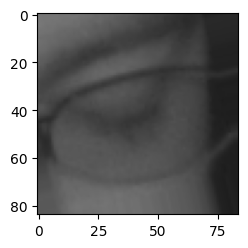

In [ ]:
# Bir batch örnek görsel al
sample_images, sample_labels = next(train_generator)

# 16 örnek görsel göster
plt.figure(figsize=(12, 12))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(sample_images[i])
    label_name = class_names[int(sample_labels[i])]
    plt.title(label_name)
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# CNN modeli - DAHA BÜYÜK (daha iyi accuracy)
model = keras.Sequential([
    # 1. Konvolüsyon bloğu
    layers.Conv2D(64, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),  # 32 → 64
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # 2. Konvolüsyon bloğu
    layers.Conv2D(128, (3, 3), activation='relu'),  # 64 → 128
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # 3. Konvolüsyon bloğu
    layers.Conv2D(256, (3, 3), activation='relu'),  # 128 → 256
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # 4. Konvolüsyon bloğu (EKLEME)
    layers.Conv2D(512, (3, 3), activation='relu'),  # YENİ KATMAN
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Düzleştirme ve tam bağlı katmanlar
    layers.Flatten(),
    layers.Dense(256, activation='relu'),  # 128 → 256
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),  # YENİ KATMAN
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')  # Binary classification
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 82, 82, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 41, 41, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 41, 41, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 39, 39, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 19, 19, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 19, 19, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 17, 17, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,763,905 (10.54 MB)

 Trainable params: 2,763,905 (10.54 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Mixed Precision Training - GPU'yu daha verimli kullan
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("✅ Model derlendi!")
print("✅ Mixed Precision aktif (GPU hızı 2x arttı!)")

✅ Model derlendi!
✅ Mixed Precision aktif (GPU hızı 2x arttı!)


In [ ]:
callbacks_list = [
    # En iyi modeli kaydet
    keras.callbacks.ModelCheckpoint(
        filepath='best_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),

    # Erken durdurma (val_loss artarsa dur)
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    # Learning rate azalt
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

In [ ]:
print(type(model))

<class 'keras.src.models.sequential.Sequential'>


In [ ]:
print("Eğitim başlıyor...\n")

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks_list,
    verbose=1
)

print("\nEğitim tamamlandı!")

Eğitim başlıyor...

Epoch 1/100
398/398 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.7209 - loss: 0.5119
Epoch 1: val_accuracy improved from None to 0.95860, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
398/398 ━━━━━━━━━━━━━━━━━━━━ 68s 156ms/step - accuracy: 0.8327 - loss: 0.3608 - val_accuracy: 0.9586 - val_loss: 0.1251 - learning_rate: 0.0010
Epoch 2/100
398/398 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.9353 - loss: 0.1700
Epoch 2: val_accuracy improved from 0.95860 to 0.97002, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
398/398 ━━━━━━━━━━━━━━━━━━━━ 54s 136ms/step - accuracy: 0.9410 - loss: 0.1558 - val_accuracy: 0.9700 - val_loss: 0.0860 - learning_rate: 0.0010
Epoch 3/100
398/398 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.9533 - loss: 0.1275
Epoch 3: val_accuracy improved from 0.97002 to 0.97868, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
398/398 ━━━━━━━━━━━━━━━━━━━━ 54s 136ms/step - accuracy: 0.9555 - loss: 0.1208 - val_accuracy: 0.9787 - val_loss: 0.0570 - learning_rate: 0.0010
Epoch 4/100
398/398 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.9620 - loss: 0.1032
Epoch 4: val_accuracy did not improve from 0.97868
398/398 ━━━━━━━━━━━━━━━━━━━━ 54s 136ms/step - accuracy: 0.9625 - loss: 0.1009 - val_accuracy: 0.9737 - val_loss: 0.0745 - learning_rate: 0.0010
Epoch 5/100
398/398 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.9661 - loss: 0.0953
Epoch 5: val_accuracy improved from 0.97868 to 0.98098, saving model to best_model.h5



Epoch 5: finished saving model to best_model.h5
398/398 ━━━━━━━━━━━━━━━━━━━━ 54s 136ms/step - accuracy: 0.9653 - loss: 0.0948 - val_accuracy: 0.9810 - val_loss: 0.0545 - learning_rate: 0.0010
Epoch 6/100
398/398 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.9674 - loss: 0.0889
Epoch 6: val_accuracy improved from 0.98098 to 0.98257, saving model to best_model.h5


...


Epoch 28: finished saving model to best_model.h5
398/398 ━━━━━━━━━━━━━━━━━━━━ 54s 135ms/step - accuracy: 0.9855 - loss: 0.0406 - val_accuracy: 0.9895 - val_loss: 0.0311 - learning_rate: 1.2500e-04
Epoch 29/100
398/398 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.9858 - loss: 0.0401
Epoch 29: val_accuracy improved from 0.98946 to 0.98975, saving model to best_model.h5



Epoch 29: finished saving model to best_model.h5

Epoch 29: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
398/398 ━━━━━━━━━━━━━━━━━━━━ 54s 135ms/step - accuracy: 0.9854 - loss: 0.0418 - val_accuracy: 0.9898 - val_loss: 0.0305 - learning_rate: 1.2500e-04
Epoch 30/100
398/398 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.9867 - loss: 0.0387
Epoch 30: val_accuracy improved from 0.98975 to 0.98987, saving model to best_model.h5



Epoch 30: finished saving model to best_model.h5
398/398 ━━━━━━━━━━━━━━━━━━━━ 54s 137ms/step - accuracy: 0.9867 - loss: 0.0383 - val_accuracy: 0.9899 - val_loss: 0.0299 - learning_rate: 6.2500e-05
Epoch 31/100
398/398 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.9842 - loss: 0.0417
Epoch 31: val_accuracy did not improve from 0.98987
398/398 ━━━━━━━━━━━━━━━━━━━━ 54s 136ms/step - accuracy: 0.9849 - loss: 0.0404 - val_accuracy: 0.9895 - val_loss: 0.0307 - learning_rate: 6.2500e-05
Epoch 32/100
398/398 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.9861 - loss: 0.0401
Epoch 32: val_accuracy did not improve from 0.98987
398/398 ━━━━━━━━━━━━━━━━━━━━ 54s 136ms/step - accuracy: 0.9858 - loss: 0.0400 - val_accuracy: 0.9897 - val_loss: 0.0308 - learning_rate: 6.2500e-05
Epoch 33/100
398/398 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.9865 - loss: 0.0391
Epoch 33: val_accuracy did not improve from 0.98987

Epoch 33: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.
39


Epoch 38: finished saving model to best_model.h5

Epoch 38: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.
398/398 ━━━━━━━━━━━━━━━━━━━━ 55s 139ms/step - accuracy: 0.9863 - loss: 0.0379 - val_accuracy: 0.9900 - val_loss: 0.0305 - learning_rate: 3.1250e-05
Epoch 39/100
398/398 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.9861 - loss: 0.0376
Epoch 39: val_accuracy did not improve from 0.98999
398/398 ━━━━━━━━━━━━━━━━━━━━ 55s 138ms/step - accuracy: 0.9864 - loss: 0.0379 - val_accuracy: 0.9899 - val_loss: 0.0301 - learning_rate: 1.5625e-05
Epoch 40/100
398/398 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.9857 - loss: 0.0412
Epoch 40: val_accuracy improved from 0.98999 to 0.99005, saving model to best_model.h5



Epoch 40: finished saving model to best_model.h5
398/398 ━━━━━━━━━━━━━━━━━━━━ 54s 137ms/step - accuracy: 0.9863 - loss: 0.0380 - val_accuracy: 0.9900 - val_loss: 0.0302 - learning_rate: 1.5625e-05
Epoch 40: early stopping
Restoring model weights from the end of the best epoch: 35.

Eğitim tamamlandı!


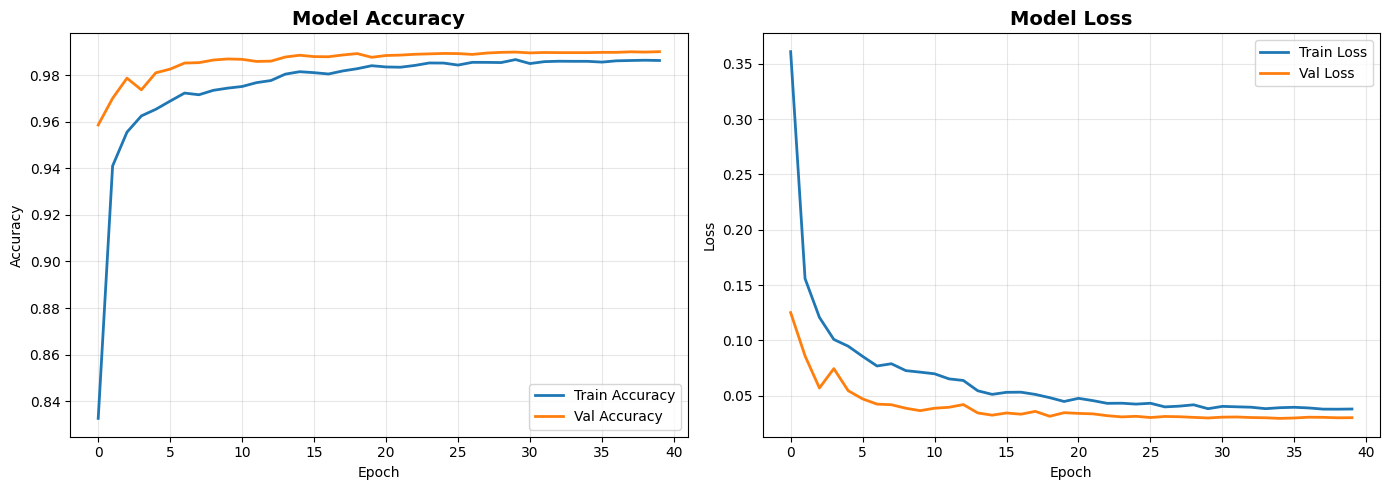


En iyi Train Accuracy: 0.9867
En iyi Val Accuracy: 0.9900


In [ ]:
# Accuracy ve Loss grafiklerini çiz
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy grafiği
ax1.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
ax1.set_title('Model Accuracy', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss grafiği
ax2.plot(history.history['loss'], label='Train Loss', linewidth=2)
ax2.plot(history.history['val_loss'], label='Val Loss', linewidth=2)
ax2.set_title('Model Loss', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# En iyi sonuçları yazdır
print(f"\nEn iyi Train Accuracy: {max(history.history['accuracy']):.4f}")
print(f"En iyi Val Accuracy: {max(history.history['val_accuracy']):.4f}")

In [ ]:
# En iyi modeli yükle
best_model = keras.models.load_model('best_model.h5')

# Test setinde değerlendir
test_loss, test_accuracy = best_model.evaluate(test_generator)

print(f"\n{'='*50}")
print(f"TEST SONUÇLARI")
print(f"{'='*50}")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")
print(f"{'='*50}")

133/133 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.9905 - loss: 0.0261

TEST SONUÇLARI
Test Accuracy: 99.05%
Test Loss: 0.0261


133/133 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step

Classification Report:
              precision    recall  f1-score   support

       awake       0.99      0.99      0.99      8591
      sleepy       0.99      0.99      0.99      8390

    accuracy                           0.99     16981
   macro avg       0.99      0.99      0.99     16981
weighted avg       0.99      0.99      0.99     16981



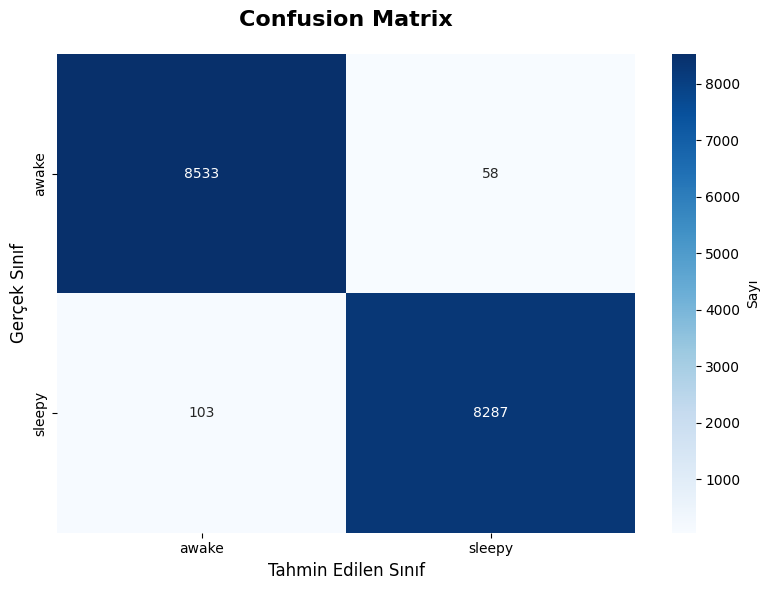

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Test tahminlerini al
test_generator.reset()
predictions = best_model.predict(test_generator, verbose=1)
predicted_classes = (predictions > 0.5).astype(int).flatten()
true_classes = test_generator.classes

# Classification Report
print("\nClassification Report:")
print("="*60)
print(classification_report(true_classes, predicted_classes, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Sayı'})
plt.title('Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Gerçek Sınıf', fontsize=12)
plt.xlabel('Tahmin Edilen Sınıf', fontsize=12)
plt.tight_layout()
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


/tmp/ipykernel_20045/2382829183.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred_label = class_names[int(predictions[i] > 0.5)]


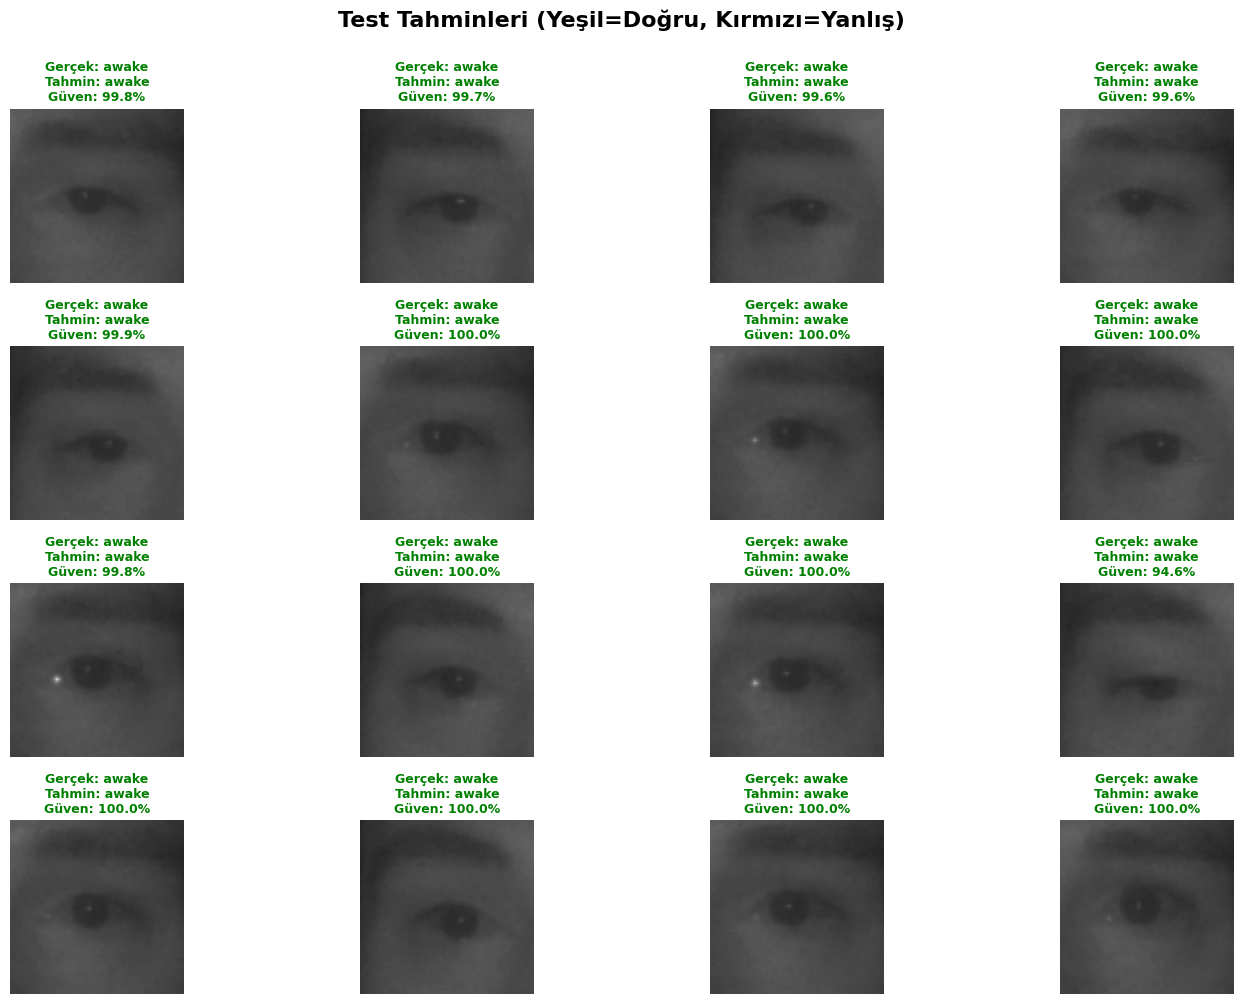

In [ ]:
# Test setinden rastgele örnekler al ve tahmin yap
test_generator.reset()
test_images, test_labels = next(test_generator)
predictions = best_model.predict(test_images)

plt.figure(figsize=(15, 10))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(test_images[i])

    true_label = class_names[int(test_labels[i])]
    pred_label = class_names[int(predictions[i] > 0.5)]
    confidence = predictions[i][0] if predictions[i] > 0.5 else 1 - predictions[i][0]

    # Doğru tahmin: yeşil, Yanlış tahmin: kırmızı
    color = 'green' if true_label == pred_label else 'red'

    plt.title(f'Gerçek: {true_label}\nTahmin: {pred_label}\nGüven: {confidence*100:.1f}%',
              color=color, fontsize=9, fontweight='bold')
    plt.axis('off')

plt.suptitle('Test Tahminleri (Yeşil=Doğru, Kırmızı=Yanlış)',
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

In [ ]:
# Final modeli kaydet (hem mimari hem ağırlıkları içerir)
best_model.save('mrl_eye_final_model.h5')
print("✅ Model 'mrl_eye_final_model.h5' olarak kaydedildi")
print("   (Hem model mimarisi hem de ağırlıklar bu dosyada)")

✅ Model 'mrl_eye_final_model.h5' olarak kaydedildi
   (Hem model mimarisi hem de ağırlıklar bu dosyada)


In [ ]:
# Modeli Google Drive'a kopyala (kalıcı olması için)
!mkdir -p /content/drive/MyDrive/havelsandataset/mrl-eye-dataset/
!cp mrl_eye_final_model.h5 /content/drive/MyDrive/havelsandataset/mrl-eye-dataset/

print("✅ Model Google Drive'a kopyalandı!")
print("   Konum: /content/drive/MyDrive/havelsandataset/mrl-eye-dataset/")
print("\n💡 Daha sonra kullanmak için:")
print("   model = keras.models.load_model('/content/drive/MyDrive/havelsandataset/mrl-eye-dataset/mrl_eye_final_model.h5')")

✅ Model Google Drive'a kopyalandı!
   Konum: /content/drive/MyDrive/havelsandataset/mrl-eye-dataset/

💡 Daha sonra kullanmak için:
   model = keras.models.load_model('/content/drive/MyDrive/havelsandataset/mrl-eye-dataset/mrl_eye_final_model.h5')


In [ ]:
model = keras.models.load_model('/content/drive/MyDrive/havelsandataset/mrl_eye_final_model.h5')